<a href="https://colab.research.google.com/github/george-marcus/ml-neural-networks/blob/main/MLP_MakeMore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# from google.colab import drive
# drive.mount('/content/drive')

%matplotlib inline

In [19]:
words = open('names.txt', 'r').read().splitlines()
# words = open('/content/drive/MyDrive/Colab Notebooks/names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
block_size = 3

In [20]:
def build_dataset(words):
  X,Y = [],[]
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X,Y

In [21]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
xtr,ytr = build_dataset(words[:n1])
xdev,ydev = build_dataset(words[n1:n2])
xte,yte = build_dataset(words[n2:])

embbedding_vectors_count = 10
hidden_layer_neurons_count = 200
vocab_size = 27
w1_std = (5/3)/((embbedding_vectors_count * block_size)**0.5)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embbedding_vectors_count, ), generator=g)
W1 = torch.randn((block_size * embbedding_vectors_count, hidden_layer_neurons_count), generator=g) * w1_std
b1 = torch.randn(hidden_layer_neurons_count, generator=g) * 0.01
W2 = torch.randn((hidden_layer_neurons_count, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C,W1,b1,W2,b2]

for p in parameters:
  p.requires_grad = True

In [ ]:
max_epochs = 200000
batch_size = 32
lossi = []

for i in range(max_epochs):
  # mini batch construct
  ix = torch.randint(0,xtr.shape[0],(batch_size,))
  Xb = xtr[ix]
  Yb = ytr[ix]
  # forward pass
  emb = C[Xb]
  hpreact = emb.view(-1, block_size * embbedding_vectors_count) @ W1 + b1
  hpreact = (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits,Yb)
  #  backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 10000 else 0.01

  for p in parameters:
    p.data += -lr * p.grad
    
  if i % 1000 == 0:
    print(f'{i:7d}/{max_epochs:7d}: {loss.item():.4f}')
    lossi.append(loss.item())

      0/ 200000: 3.3426
   1000/ 200000: 2.2168
   2000/ 200000: 2.2890
   3000/ 200000: 2.6321
   4000/ 200000: 2.5901
   5000/ 200000: 2.0244
   6000/ 200000: 2.2515
   7000/ 200000: 2.2661
   8000/ 200000: 2.0900
   9000/ 200000: 2.3387
  10000/ 200000: 2.0831
  11000/ 200000: 1.8142
  12000/ 200000: 2.7836
  13000/ 200000: 2.3677
  14000/ 200000: 2.5420
  15000/ 200000: 2.5229
  16000/ 200000: 2.1648
  17000/ 200000: 2.2313
  18000/ 200000: 2.3569
  19000/ 200000: 2.3985
  20000/ 200000: 2.1557
  21000/ 200000: 2.4008
  22000/ 200000: 1.9389
  23000/ 200000: 2.1708
  24000/ 200000: 2.2645
  25000/ 200000: 2.4391
  26000/ 200000: 1.8195
  27000/ 200000: 2.2103
  28000/ 200000: 2.1205
  29000/ 200000: 2.0171
  30000/ 200000: 2.1840
  31000/ 200000: 2.0728
  32000/ 200000: 2.1217
  33000/ 200000: 1.9510
  34000/ 200000: 2.3502
  35000/ 200000: 2.2624
  36000/ 200000: 2.1851
  37000/ 200000: 2.4022
  38000/ 200000: 2.6120
  39000/ 200000: 2.0230
  40000/ 200000: 2.2763
  41000/ 200000:

In [23]:
# plt.figure(figsize=(20,10))
# plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [24]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (xtr,ytr),
        'dev': (xdev,ydev),
        'test': (xte,yte),
    }[split]
    emb = C[x]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,y)
    print(loss.item())
    
split_loss('train')
split_loss('dev')

2.0820765495300293
2.1296982765197754


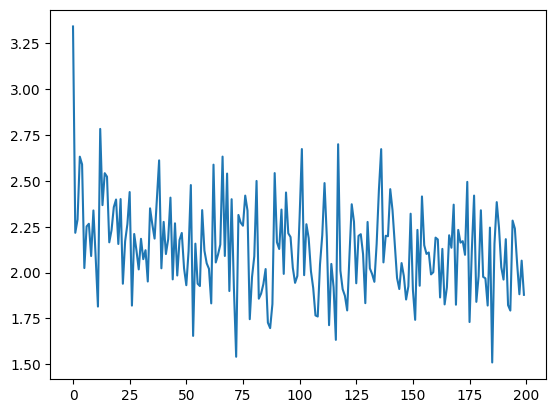

In [25]:
plt.plot(lossi)

In [26]:
# sample from the model
for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor(context)]
    h = torch.tanh(emb.view(1,-1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

mehritt.
katgafnan.
joannyn.
delle.
gurick.
aveeb.
shed.
atra.
esaidenecky.
aman.
logo.
sannel.
rosegersmin.
ceon.
anite.
bard.
livia.
takefire.
ren.
carielyna.
